In [1]:
import sys
print(sys.executable)
#%cd C:\School\yolo5\yolov5
import os
print(os.getcwd())
#hi, please change directory to your yolov5 folder with the data files
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

C:\Users\nothi\anaconda3\envs\yolov5\python.exe
C:\Users\nothi
2.7.1+cu118
True
1
NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
from ultralytics import YOLO
print("ultralytics imported ok")

ultralytics imported ok


In [9]:
model = YOLO('06-object-detection-using-yolo/yolov8n.pt')

In [10]:
#loads pretrained nano small model
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [11]:

#should work if your notebook is running from the yolov5 folder.
results = model("data/images/bus.jpg")


image 1/1 C:\School\yolo5\yolov5\data\images\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 188.5ms
Speed: 11.8ms preprocess, 188.5ms inference, 24.6ms postprocess per image at shape (1, 3, 640, 480)


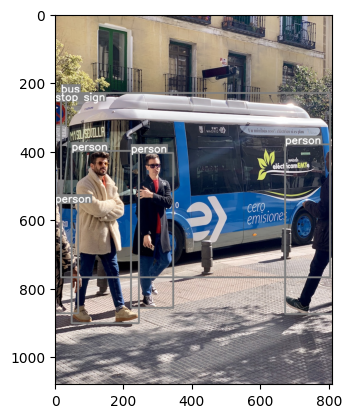

In [12]:
from ultralytics.utils.plotting import Annotator
import matplotlib.pyplot as plt
import cv2

annotator = Annotator(cv2.cvtColor(results[0].orig_img, cv2.COLOR_BGR2RGB))
boxes = results[0].boxes
for box in boxes:
    b = box.xyxy[0]  # get box coordinates in (left, top, right, bottom) format
    c = box.cls
    annotator.box_label(b, model.names[int(c)])

plt.imshow(annotator.result())


In [13]:
#this should work if you are in the folder, with relative path
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model("data/images/zidane.jpg")


image 1/1 C:\School\yolo5\yolov5\data\images\zidane.jpg: 384x640 2 persons, 1 tie, 135.8ms
Speed: 4.4ms preprocess, 135.8ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


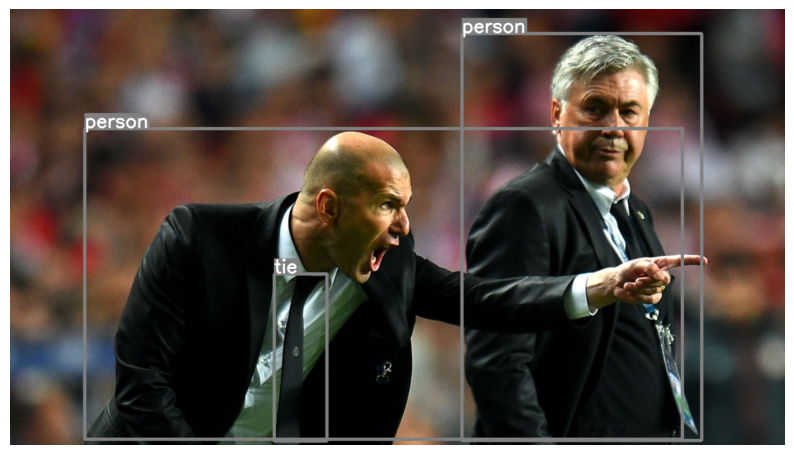

In [14]:
from ultralytics.utils.plotting import Annotator
import matplotlib.pyplot as plt
import cv2

annotator = Annotator(cv2.cvtColor(results[0].orig_img, cv2.COLOR_BGR2RGB))
boxes = results[0].boxes

for box in boxes:
    b = box.xyxy[0]
    c = box.cls
    annotator.box_label(b, model.names[int(c)])

plt.figure(figsize=(10, 8))
plt.imshow(annotator.result())
plt.axis("off")
plt.show()

In [16]:
#sees 2 people and a tie
#what not to do 
#don't train from stratch
"""
from ultralytics import YOLO

model = YOLO('06-object-detection-using-yolo/yolov8n.yaml')  # Using yolov8n structure, but randomly initialized weights
model.info()
results = model(source='06-object-detection-using-yolo/zidane.jpg')

from ultralytics.utils.plotting import Annotator
import matplotlib.pyplot as plt
import cv2

annotator = Annotator(cv2.cvtColor(results[0].orig_img, cv2.COLOR_BGR2RGB))
boxes = results[0].boxes
for box in boxes:
    b = box.xyxy[0]  # get box coordinates in (left, top, right, bottom) format
    c = box.cls
    annotator.box_label(b, model.names[int(c)])

plt.imshow(annotator.result())
"""
from ultralytics import YOLO

model = YOLO('yolov8n.yaml')  # Using yolov8n structure, but randomly initialized weights
model.info()


YOLOv8n summary: 130 layers, 3,157,200 parameters, 3,157,184 gradients, 8.9 GFLOPs


(130, 3157200, 3157184, 8.8575488)


image 1/1 C:\School\yolo5\yolov5\data\images\zidane.jpg: 384x640 (no detections), 156.8ms
Speed: 2.6ms preprocess, 156.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


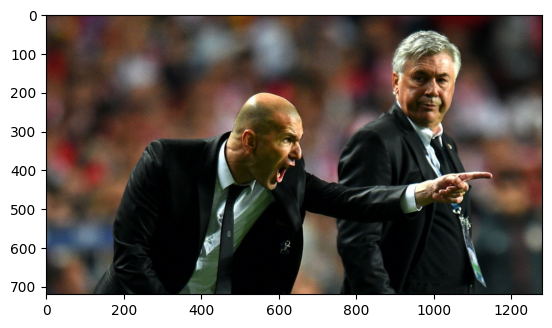

In [21]:
#%cd C:\School\yolo5\yolov5
#do your relative path
results = model(source="data/images/zidane.jpg")

from ultralytics.utils.plotting import Annotator
import matplotlib.pyplot as plt
import cv2

annotator = Annotator(cv2.cvtColor(results[0].orig_img, cv2.COLOR_BGR2RGB))
boxes = results[0].boxes
for box in boxes:
    b = box.xyxy[0]  # get box coordinates in (left, top, right, bottom) format
    c = box.cls
    annotator.box_label(b, model.names[int(c)])

plt.imshow(annotator.result())

In [4]:
from ultralytics import YOLO
#or whatever relative path your folder and files are in
#%cd C:\School\yolo5\yolov5
use_pretrained = True

if use_pretrained:
    print('Using a pretrained model')
    model = YOLO('yolov8n.pt')  # load a pretrained model
else:
    print('Using a scratch model')
    model = YOLO('yolov8n.yaml') # load a scratch model

model.info()

epochs = 1                     # quick test first
data = "lab6coco128.yml"  # 

results = model.train(
    data=data,
    epochs=epochs,
    imgsz=640,
    device=0
)


C:\Users\nothi\anaconda3\envs\yolov5\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\School\yolo5\yolov5
Using a pretrained model
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
Ultralytics 8.4.24  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=lab6coco128.yml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_sc

In [5]:
#%cd C:\School\yolo5\ or whatpath you like

C:\School\yolo5


C:\Users\nothi\anaconda3\envs\yolov5\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path

# Function to get the data from XML Annotation
def extract_info_from_xml(xml_file):
    root = ET.parse(xml_file).getroot()

    info_dict = {}
    info_dict["bboxes"] = []

    for elem in root:
        if elem.tag == "filename":
            info_dict["filename"] = elem.text

        elif elem.tag == "size":
            image_size = []
            for subelem in elem:
                image_size.append(int(subelem.text))
            info_dict["image_size"] = tuple(image_size)  # (w, h, c)

        elif elem.tag == "object":
            bbox = {}
            for subelem in elem:
                if subelem.tag == "name":
                    bbox["class"] = subelem.text

                elif subelem.tag == "bndbox":
                    for subsubelem in subelem:
                        bbox[subsubelem.tag] = int(subsubelem.text)

            info_dict["bboxes"].append(bbox)

    return info_dict


class_name_to_id_mapping = {
    "trafficlight": 0,
    "stop": 1,
    "speedlimit": 2,
    "crosswalk": 3
}


def convert_to_yolo(info_dict, label_output_dir, write_to_file=True):
    lines = []

    for b in info_dict["bboxes"]:
        if b["class"] not in class_name_to_id_mapping:
            print("Skipping invalid class:", b["class"])
            continue

        class_id = class_name_to_id_mapping[b["class"]]

        # YOLO box format
        b_center_x = (b["xmin"] + b["xmax"]) / 2
        b_center_y = (b["ymin"] + b["ymax"]) / 2
        b_width = b["xmax"] - b["xmin"]
        b_height = b["ymax"] - b["ymin"]

        image_w, image_h, image_c = info_dict["image_size"]

        # normalize
        b_center_x /= image_w
        b_center_y /= image_h
        b_width /= image_w
        b_height /= image_h

        lines.append(f"{class_id} {b_center_x:.6f} {b_center_y:.6f} {b_width:.6f} {b_height:.6f}")

    if write_to_file:
        os.makedirs(label_output_dir, exist_ok=True)
        txt_name = Path(info_dict["filename"]).stem + ".txt"
        save_file_name = os.path.join(label_output_dir, txt_name)

        with open(save_file_name, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))
    else:
        return lines

In [7]:
from pathlib import Path

import os

print(os.getcwd())
print(os.listdir("road-sign-detection"))

C:\School\yolo5
['annotations', 'images', 'Readme.md']


In [8]:
#from pathlib import Path

root = Path("road-sign-detection")
xml_dir = root / "annotations"

one_xml = next(xml_dir.glob("*.xml"))

info = extract_info_from_xml(one_xml)
print(one_xml.name)
print(info["filename"])
print(info["image_size"])
print(info["bboxes"][:2])

road0.xml
road0.png
(267, 400, 3)
[{'class': 'trafficlight', 'xmin': 98, 'ymin': 62, 'xmax': 208, 'ymax': 232}]


In [9]:
convert_to_yolo(
    info,
    label_output_dir=root / "labels" / "test_one",
    write_to_file=True
)

In [10]:
print(list((root / "labels" / "test_one").glob("*.txt"))[:5])

[WindowsPath('road-sign-detection/labels/test_one/road0.txt')]


In [11]:
#now convert all 
#from pathlib import Path

root = Path("road-sign-detection")
xml_dir = root / "annotations"
label_dir = root / "labels" / "all"

for xml_file in xml_dir.glob("*.xml"):
    info = extract_info_from_xml(xml_file)
    convert_to_yolo(info, label_output_dir=label_dir, write_to_file=True)

print("Done converting XML -> YOLO txt")
print("Number of txt files:", len(list(label_dir.glob("*.txt"))))

Done converting XML -> YOLO txt
Number of txt files: 877


In [12]:
import random
import shutil
from pathlib import Path

random.seed(42)

root = Path("road-sign-detection")
img_src = root / "images"
lbl_src = root / "labels" / "all"

all_images = []
for ext in ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]:
    all_images.extend(img_src.glob(ext))

all_images = sorted(all_images)
random.shuffle(all_images)

n = len(all_images)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_imgs = all_images[:n_train]
val_imgs = all_images[n_train:n_train + n_val]
test_imgs = all_images[n_train + n_val:]

splits = {
    "train": train_imgs,
    "val": val_imgs,
    "test": test_imgs,
}

for split in ["train", "val", "test"]:
    (root / "images" / split).mkdir(parents=True, exist_ok=True)
    (root / "labels" / split).mkdir(parents=True, exist_ok=True)

for split, files in splits.items():
    for img_path in files:
        shutil.copy2(img_path, root / "images" / split / img_path.name)

        txt_path = lbl_src / f"{img_path.stem}.txt"
        if txt_path.exists():
            shutil.copy2(txt_path, root / "labels" / split / txt_path.name)
        else:
            print("Missing label for:", img_path.name)

print("Done splitting dataset")
print("train:", len(train_imgs), "val:", len(val_imgs), "test:", len(test_imgs))

Done splitting dataset
train: 1227 val: 263 test: 264


In [13]:
#from pathlib import Path

root = Path("road-sign-detection")

for split in ["train", "val", "test"]:
    n_imgs = len(list((root / "images" / split).glob("*")))
    n_lbls = len(list((root / "labels" / split).glob("*.txt")))
    print(split, "images:", n_imgs, "labels:", n_lbls)

train images: 787 labels: 787
val images: 239 labels: 239
test images: 243 labels: 243


In [14]:
yaml_text = """path: road-sign-detection
train: images/train
val: images/val
test: images/test

nc: 4
names: ["trafficlight", "stop", "speedlimit", "crosswalk"]
"""

with open("roadsigns.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_text)

print("roadsigns.yaml written")

roadsigns.yaml written


In [15]:
#Construct a pretrained YOLO and capture its performance on the test set without any training
from ultralytics import YOLO

model = YOLO("yolov8n.pt")   # pretrained tiny/nano model
metrics = model.val(
    data="roadsigns.yaml",
    split="test",
    imgsz=640,
    device=0,
    name="roadsigns_pretrained_testonly"
)

print("mAP50-95 =", metrics.box.map)
print("mAP50    =", metrics.box.map50)
print("mAP75    =", metrics.box.map75)

Ultralytics 8.4.24  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 116.19.7 MB/s, size: 201.7 KB)
val: Scanning C:\School\yolo5\road-sign-detection\labels\test... 243 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 243/243 390.1it/s 0.6s0.1s
val: New cache created: C:\School\yolo5\road-sign-detection\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.7it/s 4.3s0.2s
                   all        243        343   0.000397     0.0266   0.000226   8.26e-05
                person         32         47    0.00159      0.106   0.000904   0.000331
               bicycle         29         29          0          0          0          0
                   car        188        218          0          0          0          0
            motorcyc

In [3]:
"""The pretrained YOLOv8n model achieved extremely poor performance on the road-sign test set without fine-tuning 
This is expected because the pretrained model is trained on COCO classes,
while the target dataset uses custom road-sign classes. 
Therefore, before training, the model class semantics do not align with the dataset labels. mAP50-95 = 8.263411582844934e-05
mAP50    = 0.00022598045805112996
mAP75    = 4.2602266410713175e-05
"""
# step 2 Construct a pretrained YOLO. Train it for 5 epochs on the training set. Then capture its performance on the test set.
from ultralytics import YOLO
%cd C:\School\yolo5
model = YOLO("yolov8n.pt")

train_results = model.train(
    data="roadsigns.yaml",
    epochs=5,
    imgsz=640,
    batch=8,
    device=0,
    name="roadsigns_pretrained_5ep_bs8"
)

C:\Users\nothi\anaconda3\envs\yolov5\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\School\yolo5
Ultralytics 8.4.24  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=roadsigns.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadsigns_pretrained_5ep_bs8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

In [1]:
import torch
torch.cuda.empty_cache()

In [4]:
#evaluation 
from ultralytics import YOLO

best_model = YOLO("runs/detect/roadsigns_pretrained_5ep_bs8/weights/best.pt")

metrics = best_model.val(
    data="roadsigns.yaml",
    split="test",
    imgsz=640,
    device=0,
    name="roadsigns_pretrained_5ep_bs8_test"
)

print("P        =", metrics.box.mp)
print("R        =", metrics.box.mr)
print("mAP50    =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)

Ultralytics 8.4.24  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.60.1 ms, read: 216.272.3 MB/s, size: 260.6 KB)
val: Scanning C:\School\yolo5\road-sign-detection\labels\test.cache... 243 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 243/243  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.0it/s 5.4s0.2s
                   all        243        343      0.938      0.889      0.928      0.773
          trafficlight         32         47      0.872      0.723      0.835      0.568
                  stop         29         29          1      0.983      0.995      0.925
            speedlimit        188        218      0.981      0.991      0.988      0.884
             crosswalk         45         49      0.899      0.857      0.894      0.718
Speed: 5.3ms prep

In [5]:
from ultralytics import YOLO
#step3 scratch model 5
model = YOLO("yolov8n.yaml")

train_results = model.train(
    data="roadsigns.yaml",
    epochs=5,
    imgsz=640,
    batch=8,
    device=0,
    name="roadsigns_scratch_5ep_bs8"
)

Ultralytics 8.4.24  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=roadsigns.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadsigns_scratch_5ep_bs8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

In [6]:
#test after 5 stratch train
best_model = YOLO("runs/detect/roadsigns_scratch_5ep_bs8/weights/best.pt")

metrics = best_model.val(
    data="roadsigns.yaml",
    split="test",
    imgsz=640,
    device=0,
    name="roadsigns_scratch_5ep_bs8_test"
)

print("P        =", metrics.box.mp)
print("R        =", metrics.box.mr)
print("mAP50    =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)

Ultralytics 8.4.24  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLOv8n summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 225.099.9 MB/s, size: 260.6 KB)
val: Scanning C:\School\yolo5\road-sign-detection\labels\test.cache... 243 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 243/243  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.0it/s 5.4s0.2s
                   all        243        343      0.695      0.327      0.363      0.217
          trafficlight         32         47          1          0      0.026    0.00569
                  stop         29         29      0.856      0.205      0.422      0.235
            speedlimit        188        218      0.519      0.716      0.671      0.469
             crosswalk         45         49      0.403      0.388      0.332      0.158
Speed: 6.8ms pr

In [7]:
from ultralytics import YOLO
#step3 scratch model 15
model = YOLO("yolov8n.yaml")

train_results = model.train(
    data="roadsigns.yaml",
    epochs=15,
    imgsz=640,
    batch=8,
    device=0,
    name="roadsigns_scratch_15ep_bs8"
)

Ultralytics 8.4.24  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=roadsigns.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadsigns_scratch_5ep_bs82, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

In [9]:
#test 15
best_model = YOLO("runs/detect/roadsigns_scratch_15ep_bs8/weights/best.pt")

metrics = best_model.val(
    data="roadsigns.yaml",
    split="test",
    imgsz=640,
    device=0,
    name="roadsigns_scratch_15ep_bs8_test"
)

print("P        =", metrics.box.mp)
print("R        =", metrics.box.mr)
print("mAP50    =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)

Ultralytics 8.4.24  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLOv8n summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 212.2110.1 MB/s, size: 260.6 KB)
val: Scanning C:\School\yolo5\road-sign-detection\labels\test.cache... 243 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 243/243  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.4it/s 4.8s0.2s
                   all        243        343      0.746      0.599      0.663        0.5
          trafficlight         32         47      0.289     0.0213      0.133     0.0549
                  stop         29         29      0.854      0.724      0.791      0.627
            speedlimit        188        218      0.917      0.915      0.947      0.775
             crosswalk         45         49      0.923      0.735      0.779      0.542
Speed: 3.5ms p

In [10]:
#Q4 you can run this code if you have pandas
"""
import pandas as pd
import matplotlib.pyplot as plt

# 1) Put your lab results into a table
df = pd.DataFrame([
    {
        "Setting": "Pretrained, no training",
        "Init": "yolov8n.pt",
        "Epochs": 0,
        "P": 0.0004,
        "R": 0.0266,
        "mAP50": 0.000226,
        "mAP50-95": 0.0000826,
    },
    {
        "Setting": "Pretrained + fine-tuning",
        "Init": "yolov8n.pt",
        "Epochs": 5,
        "P": 0.938,
        "R": 0.889,
        "mAP50": 0.928,
        "mAP50-95": 0.773,
    },
    {
        "Setting": "Scratch",
        "Init": "yolov8n.yaml",
        "Epochs": 5,
        "P": 0.695,
        "R": 0.327,
        "mAP50": 0.363,
        "mAP50-95": 0.217,
    },
    {
        "Setting": "Scratch",
        "Init": "yolov8n.yaml",
        "Epochs": 15,
        "P": 0.746,
        "R": 0.599,
        "mAP50": 0.663,
        "mAP50-95": 0.500,
    },
])

# 2) Print it in the console
print(df.to_string(index=False))

# 3) Make a picture of the table
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

plt.tight_layout()

# 4) Save the table picture
plt.savefig("performance_table.png", dpi=300, bbox_inches="tight")
plt.show()"""


'\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# 1) Put your lab results into a table\ndf = pd.DataFrame([\n    {\n        "Setting": "Pretrained, no training",\n        "Init": "yolov8n.pt",\n        "Epochs": 0,\n        "P": 0.0004,\n        "R": 0.0266,\n        "mAP50": 0.000226,\n        "mAP50-95": 0.0000826,\n    },\n    {\n        "Setting": "Pretrained + fine-tuning",\n        "Init": "yolov8n.pt",\n        "Epochs": 5,\n        "P": 0.938,\n        "R": 0.889,\n        "mAP50": 0.928,\n        "mAP50-95": 0.773,\n    },\n    {\n        "Setting": "Scratch",\n        "Init": "yolov8n.yaml",\n        "Epochs": 5,\n        "P": 0.695,\n        "R": 0.327,\n        "mAP50": 0.363,\n        "mAP50-95": 0.217,\n    },\n    {\n        "Setting": "Scratch",\n        "Init": "yolov8n.yaml",\n        "Epochs": 15,\n        "P": 0.746,\n        "R": 0.599,\n        "mAP50": 0.663,\n        "mAP50-95": 0.500,\n    },\n])\n\n# 2) Print it in the console\nprint(df.to_string(in

In [ ]:
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Pick a few test images
test_dir = Path("road-sign-detection/images/test")

# Option A: first 4 images
sample_images = sorted(test_dir.glob("*.png"))[:4]

# If your test images are jpg instead, use:
# sample_images = sorted(test_dir.glob("*.jpg"))[:4]

print("Sample images:")
for p in sample_images:
    print(p)

# Load the 4 models/settings
models = {
    "PTNaiveQ1 (0 ep)": YOLO("yolov8n.pt"),
    "Pretrained (5 ep)": YOLO("runs/detect/roadsigns_pretrained_5ep_bs8/weights/best.pt"),
    "Scratch5 (5 ep)": YOLO("runs/detect/roadsigns_scratch_5ep_bs8/weights/best.pt"),
    "Scratch15 (15 ep)": YOLO("runs/detect/roadsigns_scratch_15ep_bs8/weights/best.pt"),
}

# Show side-by-side qualitative comparison
n_rows = len(sample_images)
n_cols = len(models)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

# If only one row, make axes 2D-like
if n_rows == 1:
    axes = [axes]

for i, img_path in enumerate(sample_images):
    for j, (title, model) in enumerate(models.items()):
        results = model(str(img_path))
        annotated_bgr = results[0].plot()   # returns annotated image
        annotated_rgb = annotated_bgr[..., ::-1]  # BGR -> RGB for matplotlib

        ax = axes[i][j]
        ax.imshow(annotated_rgb)
        ax.set_title(f"{title}\n{img_path.name}", fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.savefig("qualitative_results_grid.png", dpi=300, bbox_inches="tight")
plt.show()

Sample images:
road-sign-detection\images\test\road0.png
road-sign-detection\images\test\road100.png
road-sign-detection\images\test\road103.png
road-sign-detection\images\test\road104.png

image 1/1 C:\School\yolo5\road-sign-detection\images\test\road0.png: 640x448 1 traffic light, 24.2ms
Speed: 5.0ms preprocess, 24.2ms inference, 5.0ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 C:\School\yolo5\road-sign-detection\images\test\road0.png: 640x448 1 trafficlight, 20.1ms
Speed: 4.8ms preprocess, 20.1ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 C:\School\yolo5\road-sign-detection\images\test\road0.png: 640x448 1 speedlimit, 20.7ms
Speed: 4.5ms preprocess, 20.7ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 C:\School\yolo5\road-sign-detection\images\test\road0.png: 640x448 1 stop, 1 speedlimit, 19.6ms
Speed: 5.3ms preprocess, 19.6ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 C:\